# Test 6-layered Deep CNN Model on Test Set

### Importing Libraries and Modules


In [1]:
# Deeplearning Libraries
import torch
import torch.nn as nn
from torchvision import datasets, transforms
from torch.utils.data import DataLoader

# import data handling libraries
import pandas as pd
import numpy as np

# import roc-auc from sklearn
from sklearn.metrics import roc_curve, auc, roc_auc_score

# import visualization libaries
import matplotlib.pyplot as plt
import seaborn as sns

# import custom modules for test, architecture, and graph generations
from modules.helper.tester import test
from modules.helper.calculate_metrics import calculate_metrics
from modules.helper.confusion_matrix_gen import plot_confusion_matrix
from modules.architectures.Architecture import Architecture

### Load Test Sets
Use datasets, transforms and DataLoader to create a test set with image size 112x112 and batch size 32.

In [2]:
torch.manual_seed(41)


transform = transforms.Compose([
    transforms.Resize((112,112)),
    transforms.ToTensor()
])

test_data_set = datasets.ImageFolder("./datasets/final_dataset/test", transform=transform)

test_loader = DataLoader(
    test_data_set,
    batch_size=1, 
    num_workers=4, 
    persistent_workers=True, 
    pin_memory=True, 
)

print("TEST SET CREATED!")

TEST SET CREATED!


### Create Model using Architecture and Custom Module Generator

In [3]:
# create model Architecture
model = Architecture()

def add_conv_layers(model, layers=1, skip_pool=0):
    # define in and out channels
    in_channels = 3
    out_channels = 8
    # size
    size = 112
    # skip pool increase by one for calculation
    skip_pool = skip_pool+1
    # save a trainable parameters
    total_conv_params = 0
    # loop each layers to add on model
    for layer in range(layers):
        # Convolutional Layer
        model.add(
            nn.Conv2d(in_channels, out_channels, 3, 1, 1),
            nn.BatchNorm2d(out_channels),
            nn.ReLU()
        )
        # calculate trainable params
        total_conv_params += (((3*3*in_channels) + 1) * out_channels) + (2*out_channels)
        # Pooling Layer
        if  (layer + 1) % skip_pool==0:
            model.add(nn.MaxPool2d(2,2))
            size = size//2
        # update in and out channels
        if (layer<layers-1):
            in_channels = out_channels
            out_channels = out_channels*2
    # return total convolutional layer parameters
    return total_conv_params, out_channels, size

params, channels, size = add_conv_layers(model, 6, 1)

print(f"Total Convolutional Parameters: {params}")
print(f"Final Convolutional Out Channels: {channels}")
print(f"Final Convolutional Size: {size}")

flatten_size = channels * size * size

l1_param = flatten_size * channels + channels

l2_param = channels * 36 + 36

total_params = params + l1_param + l2_param

model.add(
    nn.Flatten(),
    nn.Linear(flatten_size, channels),
    nn.ReLU(),
    nn.Linear(channels, 36)
)

print(f"TOTAL TRAINABLE PARAMETERS = {total_params}")

Total Convolutional Parameters: 394560
Final Convolutional Out Channels: 256
Final Convolutional Size: 14
TOTAL TRAINABLE PARAMETERS = 13249124


### Test exact model epoch 29

In [4]:
model_path = "./documentations/experiments/tika-6cnn-aug/models/epoch_29.pt"

In [5]:
model.to("cuda")
# load checkpoint
checkpoint = torch.load(model_path, "cuda")
# test model
model.load_state_dict(checkpoint)
# eval model
model.eval()

Architecture(
  (layers): ModuleList(
    (0): Sequential(
      (0): Conv2d(3, 8, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (1): BatchNorm2d(8, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
      (2): ReLU()
    )
    (1): Sequential(
      (0): Conv2d(8, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (1): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
      (2): ReLU()
    )
    (2): Sequential(
      (0): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    )
    (3): Sequential(
      (0): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
      (2): ReLU()
    )
    (4): Sequential(
      (0): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_r

In [6]:
model.eval()

criterion = nn.CrossEntropyLoss()

all_preds = []
all_targets = []
all_confidence = []
all_probabilities = []
total_loss = 0

with torch.no_grad():
    for x, y in test_loader:
        x = x.to("cuda")
        y = y.to("cuda")

        output = model(x)

        # Calculate loss
        loss = criterion(output, y)
        total_loss += loss.item()

        # Convert logits into class probabilities
        probabilities = torch.softmax(output, dim=1)

        # Get predicted class and its confidence
        confidence, prediction = torch.max(probabilities, dim=1)

        all_preds.append(prediction)
        all_confidence.append(confidence)
        all_targets.append(y)
        all_probabilities.append(probabilities)

# Combine results from all batches
all_preds = torch.cat(all_preds)
all_targets = torch.cat(all_targets)
all_confidence = torch.cat(all_confidence)

average_loss = total_loss / len(test_loader)

In [7]:
metric = calculate_metrics(all_targets, all_preds, prefix="_test")

In [8]:
# Show metrics:
print("Metrics on Test Set:")
metric

Metrics on Test Set:


{'_testaccuracy': 0.9993827160493827,
 '_testprecision': 0.999384330532626,
 '_testrecall': 0.9993827160493827,
 '_testf1_score': 0.9993821594159304}

### Plot Confusion Matrix

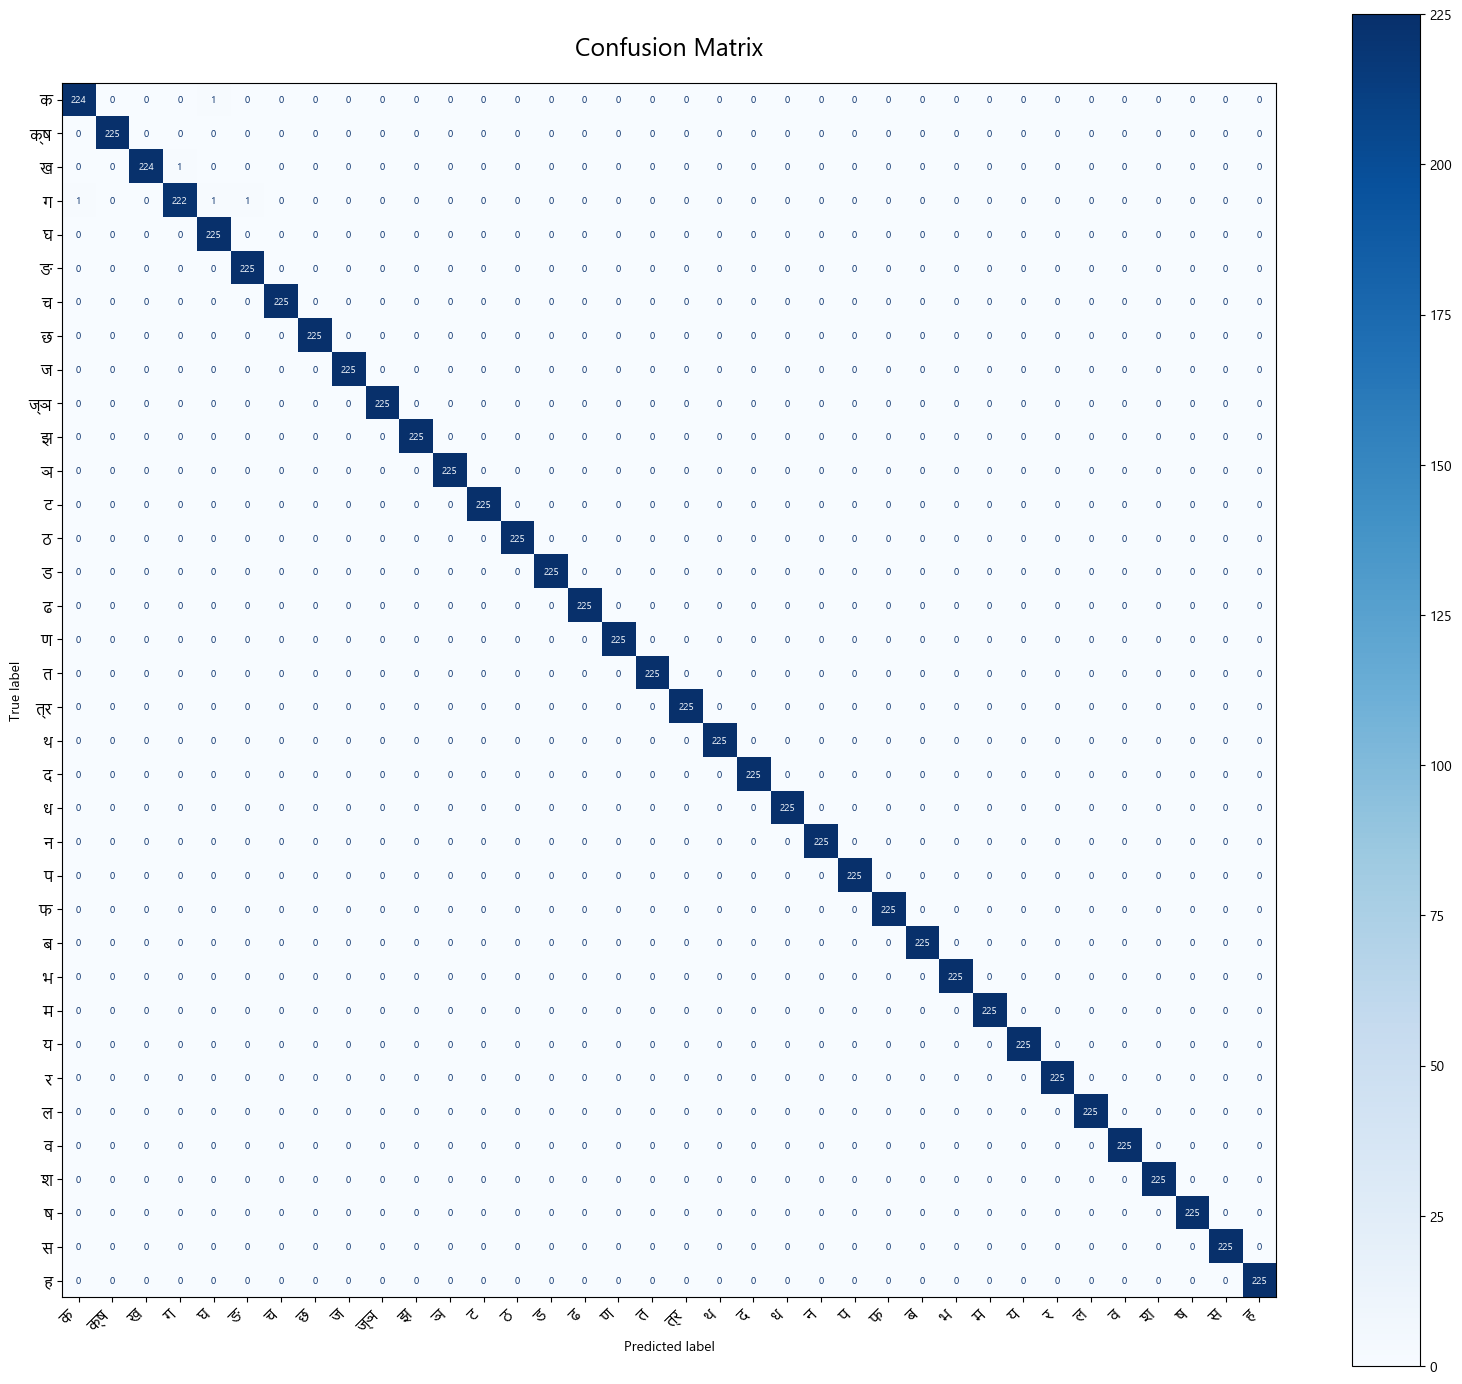

In [9]:
cm = plot_confusion_matrix(
    y_pred=all_preds.cpu().numpy(),
    y_true=all_targets.cpu().numpy(),
    save_path="./documentations/test-results/confusion-matrix-6cnn.png",
    class_names=test_loader.dataset.classes
)

### Heatmap with probabilities for each class for false Cases

In [10]:
import pandas as pd

# Combine probabilities from all batches
all_probabilities = torch.cat(all_probabilities).cpu().numpy()

# Convert predictions, targets, and confidence to NumPy
all_preds_np = all_preds.cpu().numpy()
all_targets_np = all_targets.cpu().numpy()
all_confidence_np = all_confidence.cpu().numpy()

# Get class names
class_names = test_loader.dataset.classes

# Create a DataFrame containing prediction information
results_df = pd.DataFrame({
    "True_Class_Index": all_targets_np,
    "True_Class": [class_names[i] for i in all_targets_np],
    "Predicted_Class_Index": all_preds_np,
    "Predicted_Class": [class_names[i] for i in all_preds_np],
    "Confidence": all_confidence_np,
    "Confidence_Percentage": all_confidence_np * 100,
    "Correct": all_preds_np == all_targets_np
})

# Add the probability for every class
probability_df = pd.DataFrame(
    all_probabilities,
    columns=[f"Probability_{class_name}" for class_name in class_names]
)

# Combine prediction details and all class probabilities
results_df = pd.concat(
    [results_df, probability_df],
    axis=1
)

In [11]:
pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", None)

In [12]:
results_df[results_df["Correct"]==False]

,True_Class_Index,True_Class,Predicted_Class_Index,Predicted_Class,Confidence,Confidence_Percentage,Correct,Probability_क,Probability_क्ष,Probability_ख,Probability_ग,Probability_घ,Probability_ङ,Probability_च,Probability_छ,Probability_ज,Probability_ज्ञ,Probability_झ,Probability_ञ,Probability_ट,Probability_ठ,Probability_ड,Probability_ढ,Probability_ण,Probability_त,Probability_त्र,Probability_थ,Probability_द,Probability_ध,Probability_न,Probability_प,Probability_फ,Probability_ब,Probability_भ,Probability_म,Probability_य,Probability_र,Probability_ल,Probability_व,Probability_श,Probability_ष,Probability_स,Probability_ह
99,0,क,4,घ,0.472299,47.229877,False,0.427254,3.399137e-06,0.000485,0.004426,4.722988e-01,9.500524e-02,4.704686e-04,2.525983e-06,6.823039e-07,3.306630e-05,1.048330e-08,6.009391e-07,2.687614e-09,2.708148e-11,1.057743e-10,3.074158e-08,1.614172e-12,4.288511e-08,8.174921e-09,3.557474e-10,1.145342e-12,1.065846e-05,4.755181e-10,1.987130e-07,8.472579e-07,1.202865e-06,1.210686e-10,1.119431e-09,4.006554e-11,2.451720e-10,1.381252e-07,2.966488e-08,1.463818e-11,6.169263e-08,4.055606e-08,6.676292e-06
551,2,ख,3,ग,0.612105,61.210537,False,0.001040,7.078355e-09,0.386396,0.612105,2.393796e-08,8.908517e-07,1.829554e-07,3.840664e-06,1.062396e-12,8.786858e-08,4.694544e-09,1.078978e-06,1.516784e-09,6.237825e-10,2.987021e-10,1.495940e-09,9.165914e-08,1.914483e-08,3.752311e-04,4.384614e-07,8.126317e-11,4.203024e-11,5.547589e-11,4.951663e-11,8.848049e-10,1.146572e-10,1.292965e-05,1.529477e-12,1.269333e-09,7.731273e-09,5.978826e-05,3.638186e-06,3.142418e-07,4.291162e-08,1.073650e-10,7.528168e-11
832,3,ग,4,घ,0.687067,68.706665,False,0.001970,2.765852e-09,0.000784,0.225559,6.870666e-01,8.456042e-02,5.853869e-05,2.889400e-07,9.685156e-10,1.479449e-09,5.387315e-09,9.189057e-09,2.321923e-08,6.377933e-12,3.485740e-11,1.532914e-07,7.908614e-13,3.018546e-10,5.888782e-10,9.419989e-12,1.528855e-11,6.721478e-11,8.141898e-11,1.538921e-09,3.209691e-10,8.318075e-12,1.719105e-11,1.195137e-15,1.135895e-11,5.649730e-11,1.893817e-10,6.393159e-08,4.141980e-10,1.350484e-08,3.159089e-08,1.038965e-07
854,3,ग,5,ङ,0.946012,94.601242,False,0.000156,1.078328e-07,0.040874,0.000620,8.203732e-09,9.460124e-01,2.247424e-05,1.583000e-03,2.011882e-07,2.368969e-06,1.072195e-02,8.659597e-09,7.284629e-10,5.736647e-10,7.727870e-10,3.670775e-10,2.585216e-10,4.347429e-10,5.197243e-07,4.721493e-10,2.233088e-11,2.189968e-10,8.660291e-09,1.066172e-10,5.250305e-10,5.536532e-09,1.683878e-08,8.576672e-12,2.501882e-09,6.261650e-09,3.663085e-06,2.215379e-06,1.663533e-06,6.582486e-09,1.627794e-10,2.625101e-10
872,3,ग,0,क,0.918360,91.835991,False,0.918360,7.371673e-09,0.000014,0.081347,2.725228e-04,5.230519e-06,2.389546e-09,4.085376e-07,5.258626e-10,2.777198e-09,8.420890e-11,1.039809e-07,4.124885e-09,1.244687e-09,2.046946e-09,1.857000e-08,9.896987e-10,1.668443e-09,1.254212e-09,2.351952e-09,4.252210e-10,8.903055e-12,2.514343e-11,1.758078e-08,5.772743e-09,1.408729e-09,1.581552e-09,3.874193e-10,5.183383e-10,1.346587e-09,3.194995e-08,2.696069e-09,1.312334e-09,2.469400e-08,2.763388e-08,8.473941e-09


In [15]:
correct_samples = results_df[
    results_df["Correct"] == True
].sample(frac=1).head(100)

# Round only confidence and probability values
probability_columns = [
    col for col in correct_samples.columns
    if col.startswith("Probability_")
]

columns_to_round = [
    "Confidence",
    "Confidence_Percentage"
] + probability_columns

correct_samples[columns_to_round] = (
    correct_samples[columns_to_round].round(2)
)

correct_samples

,True_Class_Index,True_Class,Predicted_Class_Index,Predicted_Class,Confidence,Confidence_Percentage,Correct,Probability_क,Probability_क्ष,Probability_ख,Probability_ग,Probability_घ,Probability_ङ,Probability_च,Probability_छ,Probability_ज,Probability_ज्ञ,Probability_झ,Probability_ञ,Probability_ट,Probability_ठ,Probability_ड,Probability_ढ,Probability_ण,Probability_त,Probability_त्र,Probability_थ,Probability_द,Probability_ध,Probability_न,Probability_प,Probability_फ,Probability_ब,Probability_भ,Probability_म,Probability_य,Probability_र,Probability_ल,Probability_व,Probability_श,Probability_ष,Probability_स,Probability_ह
2299,10,झ,10,झ,1.00,100.000000,True,0.0,0.0,0.00,0.00,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1897,8,ज,8,ज,1.00,100.000000,True,0.0,0.0,0.00,0.00,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2690,11,ञ,11,ञ,1.00,100.000000,True,0.0,0.0,0.00,0.00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3560,15,ढ,15,ढ,1.00,100.000000,True,0.0,0.0,0.00,0.00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
5240,23,प,23,प,1.00,100.000000,True,0.0,0.0,0.00,0.00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
6252,27,म,27,म,1.00,100.000000,True,0.0,0.0,0.00,0.00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2788,12,ट,12,ट,1.00,100.000000,True,0.0,0.0,0.00,0.00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1232,5,ङ,5,ङ,1.00,100.000000,True,0.0,0.0,0.00,0.00,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
5856,26,भ,26,भ,1.00,100.000000,True,0.0,0.0,0.00,0.00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
6057,26,भ,26,भ,1.00,100.000000,True,0.0,0.0,0.00,0.00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
